In [44]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy
import seaborn as sns
import sklearn.gaussian_process as gp
from scipy import stats


sys.path.append('../..')
import plot_settings
import importlib
#import multi_exp_log
import JH_symbol

from IPython.display import display, Math
from pysr import PySRRegressor, TemplateExpressionSpec
# import mean
from pysr import jl
jl.seval("using Statistics")

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    #importlib.reload(multi_exp_log)
    importlib.reload(JH_symbol)

import_reload()

# Importing data

In [45]:
DT = 1
Q0 = 17921.57581 
#(data['I'][data['trajectory'] == 10].values)[0]  * 3600 / (data['C'][data['trajectory'] == 10].values)[0]  
#print(f'Q0: {Q0:.5f} As')

In [46]:


def read_data(file_name):
    df = pd.read_csv(
        f"../Multi_data/{file_name}.txt",
        sep=';',
        comment="%"
    )
    # cols = u_par,C,t,V,I,F,u,Ue,eta,trajectory,dV,dF,soc
    #df.columns = ['u_par','C','t','V','I','F','u','Ue','eta','trajectory','dV','dF','soc']
    # Sort by time within each batch
    return df


path = f'7_merged_data'

data = read_data(path)
display(data.head())


,u_par,C,t,V,I,F,u,Ue,eta,trajectory,dV,dF,soc
0,0.4,2.2,0.0,4.239833,10.952074,0.030566,-0.057493,4.324996,-0.085164,0,-0.027881,-0.000470,0.999389
1,0.4,2.2,1.0,4.211952,10.952074,0.030096,-0.057493,4.323139,-0.111187,0,-0.016738,-0.000471,0.998778
2,0.4,2.2,2.0,4.195213,10.952074,0.029624,-0.057493,4.321278,-0.126065,0,-0.011734,-0.000471,0.998167
3,0.4,2.2,3.0,4.183479,10.952074,0.029153,-0.057493,4.319417,-0.135938,0,-0.006706,-0.000471,0.997556
4,0.4,2.2,4.0,4.176773,10.952074,0.028682,-0.057493,4.317557,-0.140783,0,-0.005763,-0.000471,0.996944


To deal with more reasonable values, $F$ is measured in GN, while $\Delta u$ is measured in $10^{-5}$ m

## The sampled terrain

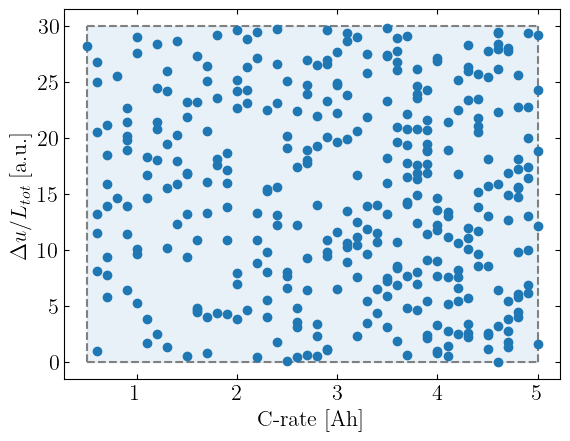

In [47]:
u_C_pairs = data.loc[data['t'] == 0, ['u_par', 'C']]
plt.xlabel('C-rate [Ah]')
plt.ylabel(r'$\Delta u / L_{tot}$ [a.u.]')
plt.vlines(0.5,0,30, color='gray', linestyle='--')
plt.vlines(5,0,30, color='gray', linestyle='--')
plt.hlines(0,0.5,5, color='gray', linestyle='--')
plt.hlines(30,0.5,5, color='gray', linestyle='--')
plt.fill_between([0.5, 5], 0, 30, color='tab:blue', alpha=0.1)
plt.plot(u_C_pairs['C'], u_C_pairs['u_par'], 'o')

# Plotting data

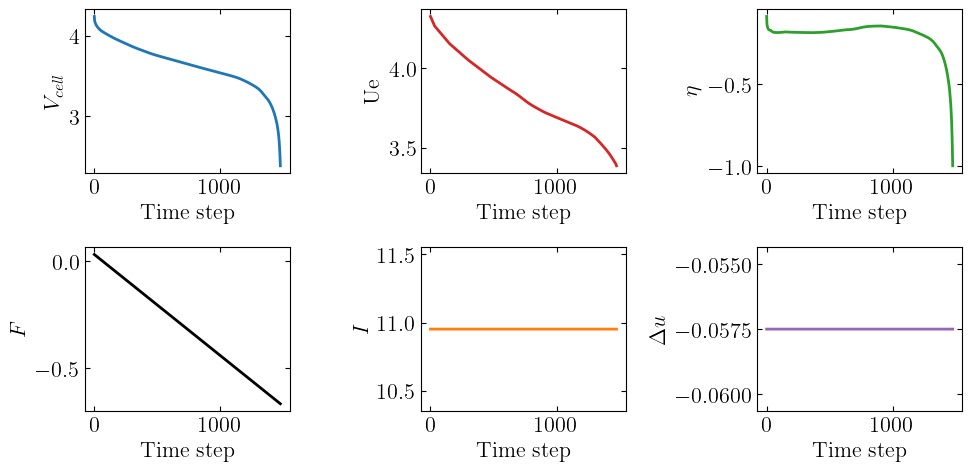

In [48]:

plot_idx = data['trajectory'] == 0
f, ax = plt.subplots(2, 3, figsize=(10, 5))
ax[0,0].plot(data['V'][plot_idx], '-', color = colors[0], lw = 2)
ax[0,0].set_xlabel('Time step')
ax[0,0].set_ylabel('$V_{cell}$')
ax[0,1].plot(data['Ue'][plot_idx], '-', color = colors[1], lw = 2)
ax[0,1].set_xlabel('Time step')
ax[0,1].set_ylabel('Ue')
ax[0,2].plot(data['eta'][plot_idx], '-', color = colors[2], lw = 2)
ax[0,2].set_xlabel('Time step')
ax[0,2].set_ylabel(r'$\eta$')
ax[1,0].plot(data['F'][plot_idx], lw = 2,color = colors[3])
ax[1,0].set_xlabel('Time step')
ax[1,0].set_ylabel(r'$F$')
ax[1,1].plot(data['I'][plot_idx], lw = 2,color = colors[4])
ax[1,1].set_xlabel('Time step')
ax[1,1].set_ylabel(r'$I$')
ax[1,2].plot(data['u'][plot_idx], lw = 2,color = colors[5])
ax[1,2].set_xlabel('Time step')
ax[1,2].set_ylabel(r'$\Delta u$')

plt.tight_layout()
plt.show()

In [49]:
import torch
import torch.nn.functional as TF

def soc_force_func(soc, variable = 'F'):   
    if variable == 'F': 
        forcing_const = 0.995
    elif variable == 'U':
        forcing_const = 0.995
    return 1 - np.exp(-(1-soc) / (1 - forcing_const));

class MyModel(nn.Module):
    def __init__(self, input_size=3, hidden_size=256): 
        super(MyModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 2)   # output size is 2 for (V_cell, F)
        )

    def forward(self, x):
        
        if True:
            Fs_raw = self.net(x)[:,0] #* force_func(soc)  # (T,)
            U1_raw = self.net(x)[:,1] 
            soc = x[:,2]
            Fs = soc_force_func(soc, variable='F') * Fs_raw;
            U1 = soc_force_func(soc, variable = 'U') * TF.softplus(U1_raw);
            
            return Fs, U1
        else:
            R0_raw, Fs_raw, U1_raw = self.net(x)[:,0], self.net(x)[:,1], self.net(x)[:,2]
            R0 = R0_raw#torch.clamp(R0_raw, 0, 1) #TF.softplus(R0_raw)  # Ensure R0 is non-negative
            Fs = Fs_raw#force_func(soc) * Fs_raw
            U1 = U1_raw # torch.clamp(U1_raw, 0, 1) #TF.softplus(U1_raw)  # Ensure U1 is non-negative

            return R0, Fs, U1

In [50]:
def load_saved_model(path = 'JH_model_8_N248'):
    m = MyModel()
    m.load_state_dict(torch.load(f'../multi_models/{path}.pth'))
    m.eval()
    return m

N_trajs = len(data['trajectory'].unique())


X = data[['I','u','soc','Ue','trajectory']].values
y = data[['V','F','trajectory']].values


x_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

split = (data['trajectory']<=int(N_trajs *0.8)).sum()

def _split_flat(arr, split = split):
    return arr[:split], arr[split:]   # Same as reshape(B * T, C)    # (B*T, 4)

x_train, x_test = _split_flat(x_tensor); y_train, y_test = _split_flat(y_tensor)

print(f'Number of trajectories in train: {int(N_trajs * 0.8)} out of {N_trajs}')

print(f'X shape {x_tensor.shape}\ty shape {y_tensor.shape}\nX-train shape: {x_train.shape}\ty-train shape: {y_train.shape}\nX-test shape: {x_test.shape}\ty-test shape: {y_test.shape}')

NN_model = load_saved_model()


Number of trajectories in train: 284 out of 356
X shape torch.Size([506172, 5])	y shape torch.Size([506172, 3])
X-train shape: torch.Size([456718, 5])	y-train shape: torch.Size([456718, 3])
X-test shape: torch.Size([49454, 5])	y-test shape: torch.Size([49454, 3])


In [ ]:
print(len(x_train[:,0]))
U1_data = np.zeros((len(x_train[:,0]),6))
    # (N_trajs*0.8, T)
for x_traj in trange(int(N_trajs *0.8)):
    traj_idx = x_train[:,-1] == x_traj
    #print(f'Trajectory {x_traj} has {traj_idx.sum()} time steps')
    # save I,u,soc, and NN_model(X_traj) for each trajectory
    NN_input = x_train[traj_idx,:]
    U1_data[traj_idx,0] =  NN_model(NN_input[:,:3])[1].detach().numpy()  # (T,)
    U1_data[traj_idx,1] =  NN_input[:,0].detach().numpy()  # I
    U1_data[traj_idx,2] =  NN_input[:,1].detach().numpy()  # u
    U1_data[traj_idx,3] =  NN_input[:,2].detach().numpy()  # soc
    U1_data[traj_idx,4] =  np.concat((np.diff(U1_data[traj_idx,0]),[np.diff(U1_data[traj_idx,0])[-1]] ))  # dU1/dt
    U1_data[traj_idx,5] =  x_train[traj_idx,-1].detach().numpy()  # trajectory index

print(U1_data.shape)  # (N_trajs*0.8, T)

df = pd.DataFrame(U1_data, columns=['U1', 'I', 'u', 'soc', 'dU1','trajectory'])
#df.to_csv('multi_models/U1_data.csv', index=False)
df.head()

456718


  0%|          | 0/284 [00:00<?, ?it/s]/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_66232/3521825897.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return 1 - np.exp(-(1-soc) / (1 - forcing_const));
  2%|▏         | 6/284 [00:00<00:05, 53.81it/s]

1476
758
5847
3846
758
3117
635
1840
1169
997
963
784


  7%|▋         | 19/284 [00:00<00:04, 57.26it/s]

1172
4347
5847
1732
1038
673
1279
1402
586
1079
2089
3441


...

 98%|█████████▊| 277/284 [00:04<00:00, 62.71it/s]

835
897
1122
1038
736
810
896
1172
784
1172
1036
963
1079
835


100%|██████████| 284/284 [00:04<00:00, 58.54it/s]

(456718, 6)


,U1,I,u,soc,dU1,trajectory
0,0.011041,10.952074,-0.057493,0.999389,0.009767,0.0
1,0.020808,10.952074,-0.057493,0.998778,0.008641,0.0
2,0.029449,10.952074,-0.057493,0.998167,0.007644,0.0
3,0.037092,10.952074,-0.057493,0.997556,0.006761,0.0
4,0.043853,10.952074,-0.057493,0.996944,0.005980,0.0


In [52]:
def get_XY(d_frame):
    for i in range(1,10):
        inds = np.arange(0,len(d_frame)) % i == 0
        if inds.sum() < 2.5e4:
            break

    X = d_frame[['dU1', 'I', 'u', 'soc']].values
    Y = d_frame['U1'].values
    print(f'Using every {i}th data point for symbolic regression, total points: {inds.sum()}')
    
    return X[inds], Y[inds]

# ECM equation

I want to solve $$V_{B} = U_{eq} - iR_0-U_1,\quad\mathrm{where}\quad \frac{dU_1}{dt} = -\frac{U_1}{R_1C_1} + \frac{i}{C_1}. $$

## $\mathrm{SoC}>0.95$

In [53]:
df_high_soc = df[df['soc'] >= 0.95]

X_data, Y_data = get_XY(df_high_soc)
print(f'X_data shape: {X_data.shape}')
print(f'Y_data shape: {Y_data.shape}')

Using every 1th data point for symbolic regression, total points: 24890
X_data shape: (24890, 4)
Y_data shape: (24890,)


In [54]:
import_reload()
model_high = JH_symbol.run_symbolic_regression(X_data, Y_data, model = None,run_id = 'high_soc')

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Text(0.5, 1.0, 'Model Complexity vs Loss')

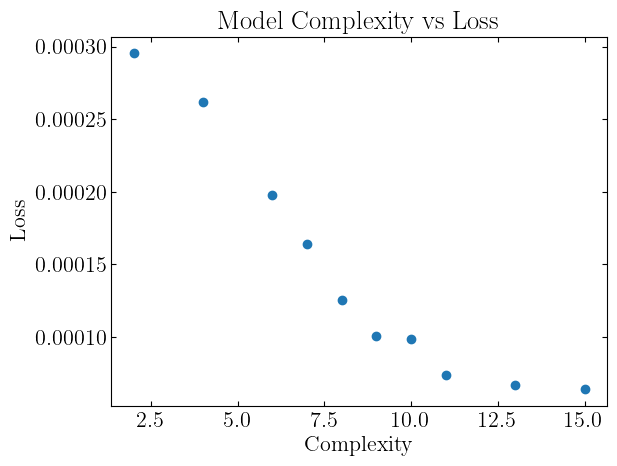

In [55]:
df_model_high = model_high.equations_
plt.scatter(df_model_high['complexity'], df_model_high['loss'])
plt.xlabel('Complexity')
plt.ylabel('Loss')
plt.title('Model Complexity vs Loss')

In [56]:

print(df_model_high['equation'][df_model_high['loss'] == df_model_high['loss'].min()].values[0])

R = (#1 / (-59.01505 - exp(#1 / #3))) + -0.099535614; C = -43.772358 + (#1 - #2)


In [57]:
for i in range(len(df_model_high)):
    print(f"Model {i}: Complexity={df_model_high['complexity'][i]}, Loss={df_model_high['loss'][i]}")
    print(f"Equation: {df_model_high['equation'][i]}\n")

Model 0: Complexity=2, Loss=0.0002952321
Equation: R = 0.10086699; C = 23.415087

Model 1: Complexity=4, Loss=0.00026210595
Equation: R = -0.10121503; C = #1 - 42.000652

Model 2: Complexity=6, Loss=0.00019760687
Equation: R = (-0.095731586 / #1) + -0.09368966; C = 23.402395

Model 3: Complexity=7, Loss=0.0001638526
Equation: R = (-0.33635646 / square(#1)) + -0.09825395; C = -23.374949

Model 4: Complexity=8, Loss=0.0001255972
Equation: R = (-0.11424552 / #1) + -0.09270356; C = #1 - 41.62552

Model 5: Complexity=9, Loss=0.0001002879
Equation: R = (-0.37837481 / square(#1)) + -0.09829916; C = #1 - 41.701504

Model 6: Complexity=10, Loss=9.826993e-05
Equation: R = sqrt((0.089612 / square(#1)) + 0.009582551); C = #1 + -41.679626

Model 7: Complexity=11, Loss=7.379119e-05
Equation: R = (#1 / (-65.8932 - exp(#1))) + -0.0995006; C = #1 + -41.668095

Model 8: Complexity=13, Loss=6.690918e-05
Equation: R = (#1 / (-70.975494 - exp(#1))) + -0.09958201; C = #1 + (-43.908016 - #2)

Model 9: Comple

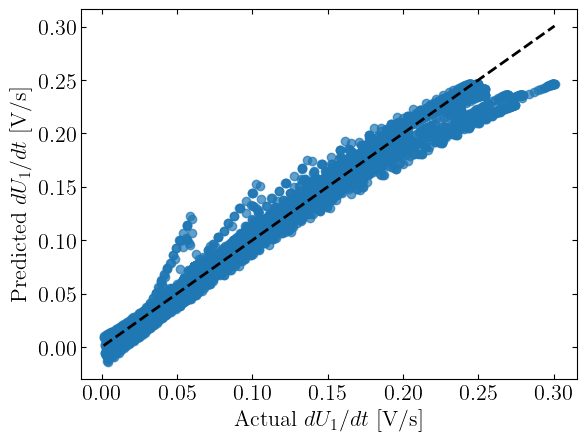

In [58]:
# Parity plot
Y_pred = model_high.predict(X_data)
plt.scatter(Y_data, Y_pred, color=colors[0],alpha = 0.7)
plt.plot([Y_data.min(), Y_data.max()], [Y_data.min(), Y_data.max()], 'k--', lw=2)
plt.xlabel('Actual $dU_1/dt$ [V/s]')
plt.ylabel('Predicted $dU_1/dt$ [V/s]')
plt.show()

Using every 1th data point for symbolic regression, total points: 24890
Using equation: R = (-0.37837481 / square(#1)) + -0.09829916; C = #1 - 41.701504 for parity plot
complexity: 9, loss: 0.0001002879


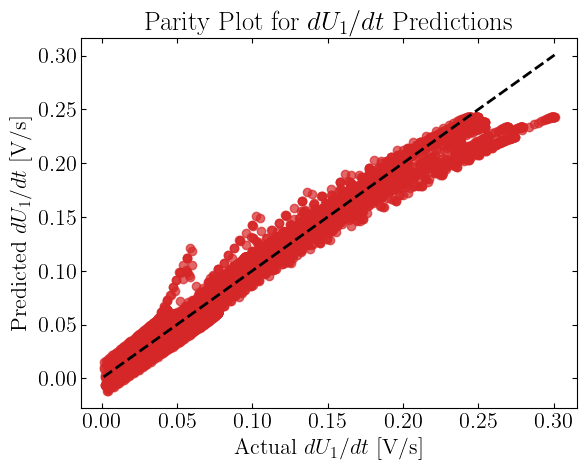

In [59]:
model_nr = 5
X_data, Y_data = get_XY(df_high_soc)
y_pred = model_high.equations_.iloc[model_nr]["lambda_format"](X_data)
print(f'Using equation: {model_high.equations_.iloc[model_nr]["equation"]} for parity plot')
print(f'complexity: {model_high.equations_.iloc[model_nr]["complexity"]}, loss: {model_high.equations_.iloc[model_nr]["loss"]}')
plt.scatter(Y_data, y_pred, color=colors[1],alpha = 0.7)
plt.plot([Y_data.min(), Y_data.max()], [Y_data.min(), Y_data.max()], 'k--', lw=2)
plt.xlabel('Actual $dU_1/dt$ [V/s]')
plt.ylabel('Predicted $dU_1/dt$ [V/s]')
plt.title('Parity Plot for $dU_1/dt$ Predictions')
plt.show()

In [60]:
# get best model and print equation and loss
best = model_high.get_best()
print("Best equation:\n",best["equation"])
print("Loss:", best["loss"])
print("Best model complexity:", best["complexity"])

Best equation:
 R = (#1 / (-65.8932 - exp(#1))) + -0.0995006; C = #1 + -41.668095
Loss: 7.379119e-05
Best model complexity: 11


## $\mathrm{SOC}<0.20$

In [61]:
df_low_soc = df[df['soc'] < 0.20]

X_data, Y_data = get_XY(df_low_soc)
print(f'X_data shape: {X_data.shape}')
print(f'Y_data shape: {Y_data.shape}')

Using every 3th data point for symbolic regression, total points: 18649
X_data shape: (18649, 4)
Y_data shape: (18649,)


In [62]:
import_reload()
model_low = JH_symbol.run_symbolic_regression(X_data, Y_data, model = None, run_id = 'low_soc')

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Text(0.5, 1.0, 'Model Complexity vs Loss')

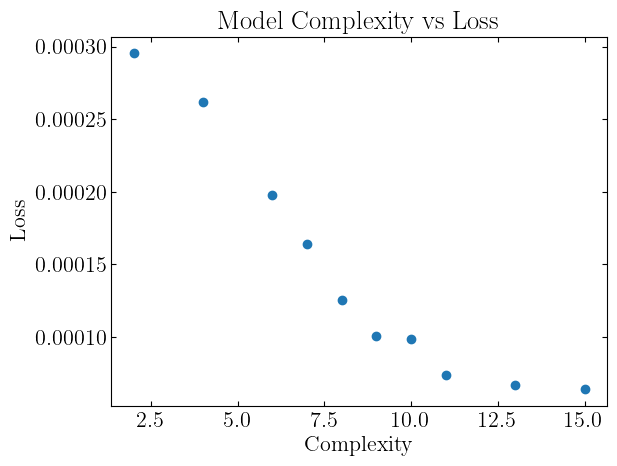

In [63]:
df_model_low = model_high.equations_
plt.scatter(df_model_low['complexity'], df_model_low['loss'])
plt.xlabel('Complexity')
plt.ylabel('Loss')
plt.title('Model Complexity vs Loss')

In [64]:
for i in range(len(df_model_low)):
    print(f"Model {i}: Complexity={df_model_low['complexity'][i]}, Loss={df_model_low['loss'][i]}")
    print(f"Equation: {df_model_low['equation'][i]}\n")

Model 0: Complexity=2, Loss=0.0002952321
Equation: R = 0.10086699; C = 23.415087

Model 1: Complexity=4, Loss=0.00026210595
Equation: R = -0.10121503; C = #1 - 42.000652

Model 2: Complexity=6, Loss=0.00019760687
Equation: R = (-0.095731586 / #1) + -0.09368966; C = 23.402395

Model 3: Complexity=7, Loss=0.0001638526
Equation: R = (-0.33635646 / square(#1)) + -0.09825395; C = -23.374949

Model 4: Complexity=8, Loss=0.0001255972
Equation: R = (-0.11424552 / #1) + -0.09270356; C = #1 - 41.62552

Model 5: Complexity=9, Loss=0.0001002879
Equation: R = (-0.37837481 / square(#1)) + -0.09829916; C = #1 - 41.701504

Model 6: Complexity=10, Loss=9.826993e-05
Equation: R = sqrt((0.089612 / square(#1)) + 0.009582551); C = #1 + -41.679626

Model 7: Complexity=11, Loss=7.379119e-05
Equation: R = (#1 / (-65.8932 - exp(#1))) + -0.0995006; C = #1 + -41.668095

Model 8: Complexity=13, Loss=6.690918e-05
Equation: R = (#1 / (-70.975494 - exp(#1))) + -0.09958201; C = #1 + (-43.908016 - #2)

Model 9: Comple

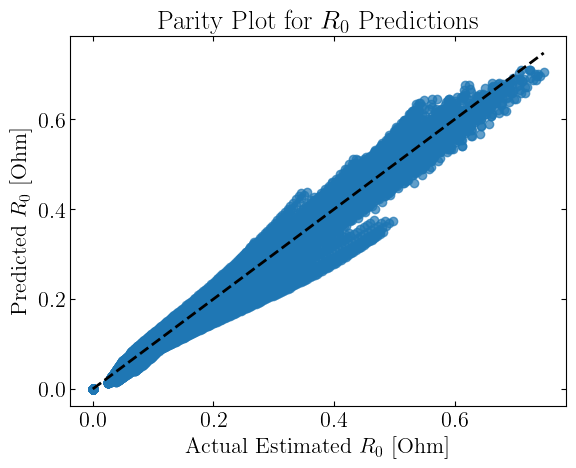

In [65]:
Y_pred = model_low.predict(X_data)
plt.scatter(Y_data, Y_pred, color=colors[0],alpha = 0.7)
plt.plot([Y_data.min(), Y_data.max()], [Y_data.min(), Y_data.max()], 'k--', lw=2)
plt.xlabel('Actual Estimated $R_0$ [Ohm]')
plt.ylabel('Predicted $R_0$ [Ohm]')
plt.title('Parity Plot for $R_0$ Predictions')
plt.show()

Using every 3th data point for symbolic regression, total points: 18649
Using equation: R = sqrt(#3) + ((#1 * -0.0075935507) - 0.4637993); C = 9.111912 for parity plot
complexity: 9, loss: 0.0008244953


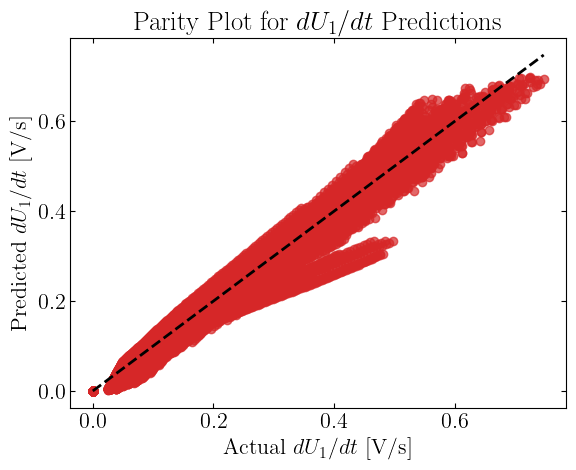

In [66]:
X_data, Y_data = get_XY(df_low_soc)
y_pred = model_low.equations_.iloc[5]["lambda_format"](X_data)
print(f'Using equation: {model_low.equations_.iloc[5]["equation"]} for parity plot')
print(f'complexity: {model_low.equations_.iloc[5]["complexity"]}, loss: {model_low.equations_.iloc[5]["loss"]}')
plt.scatter(Y_data, y_pred, color=colors[1],alpha = 0.7)
plt.plot([Y_data.min(), Y_data.max()], [Y_data.min(), Y_data.max()], 'k--', lw=2)
plt.xlabel('Actual $dU_1/dt$ [V/s]')
plt.ylabel('Predicted $dU_1/dt$ [V/s]')
plt.title('Parity Plot for $dU_1/dt$ Predictions')
plt.show()

Using every 1th data point for symbolic regression, total points: 646


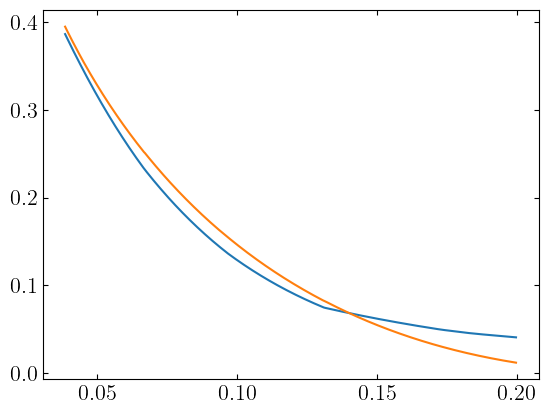

In [77]:
plt.plot(df_low_soc[df_low_soc['trajectory'] == 3]['soc'],df_low_soc[df_low_soc['trajectory'] == 3]['U1'], label='dU1/dt')
plt.plot(df_low_soc[df_low_soc['trajectory'] == 3]['soc'],model_low.equations_.iloc[5]["lambda_format"](get_XY(df_low_soc[df_low_soc['trajectory'] == 3])[0]), label='U1')

In [68]:
best = model_high.get_best()
print("Best equation:\n",best["equation"])
print("Loss:", best["loss"])

Best equation:
 R = (#1 / (-65.8932 - exp(#1))) + -0.0995006; C = #1 + -41.668095
Loss: 7.379119e-05


## $0.20<\mathrm{SOC}<0.95$

In [69]:
df_mid_soc = df[df['soc'] < 0.20]

X_data, Y_data = get_XY(df_mid_soc)
print(f'X_data shape: {X_data.shape}')
print(f'Y_data shape: {Y_data.shape}')

Using every 3th data point for symbolic regression, total points: 18649
X_data shape: (18649, 4)
Y_data shape: (18649,)


In [70]:
import_reload()
model_mid = JH_symbol.run_symbolic_regression(X_data, Y_data, model = None, run_id = 'mid_soc')

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Text(0.5, 1.0, 'Model Complexity vs Loss')

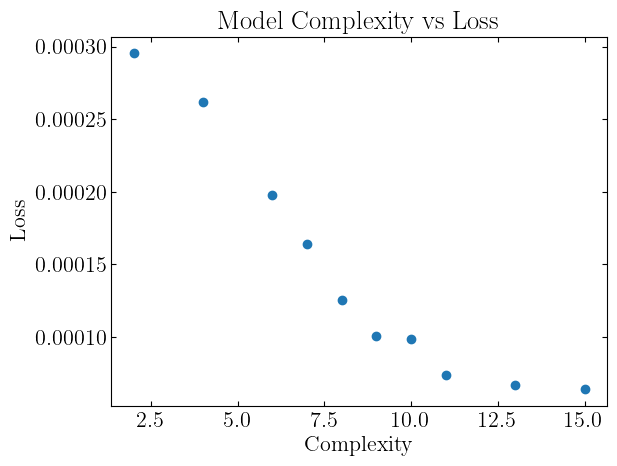

In [71]:
df_model_mid = model_high.equations_
plt.scatter(df_model_mid['complexity'], df_model_mid['loss'])
plt.xlabel('Complexity')
plt.ylabel('Loss')
plt.title('Model Complexity vs Loss')

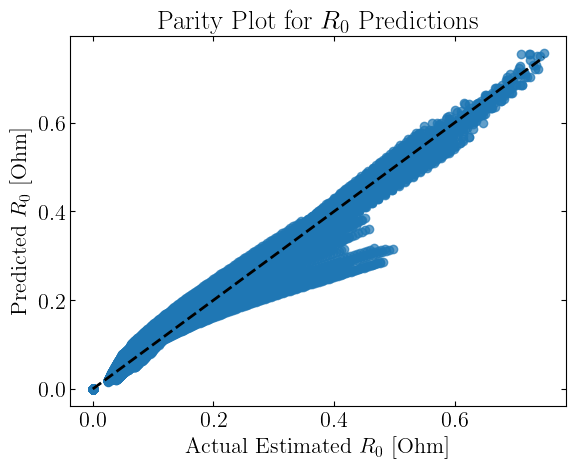

In [72]:
Y_pred = model_mid.predict(X_data)
plt.scatter(Y_data, Y_pred, color=colors[0],alpha = 0.7)
plt.plot([Y_data.min(), Y_data.max()], [Y_data.min(), Y_data.max()], 'k--', lw=2)
plt.xlabel('Actual Estimated $R_0$ [Ohm]')
plt.ylabel('Predicted $R_0$ [Ohm]')
plt.title('Parity Plot for $R_0$ Predictions')
plt.show()

Using every 3th data point for symbolic regression, total points: 18649
Using equation: R = (square(#1 * -0.014555155) + 0.2883664) - #3; C = -3.083555e-6 for parity plot
complexity: 9, loss: 0.0013611234


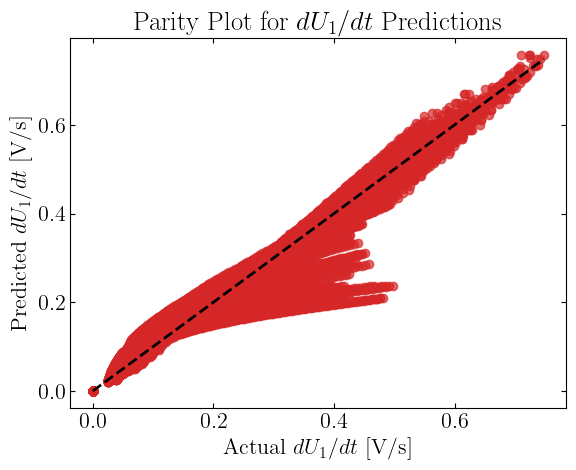

In [73]:
model_nr = 5
X_data, Y_data = get_XY(df_mid_soc)
y_pred = model_mid.equations_.iloc[model_nr]["lambda_format"](X_data)
print(f'Using equation: {model_mid.equations_.iloc[model_nr]["equation"]} for parity plot')
print(f'complexity: {model_mid.equations_.iloc[model_nr]["complexity"]}, loss: {model_mid.equations_.iloc[model_nr]["loss"]}')
plt.scatter(Y_data, y_pred, color=colors[1],alpha = 0.7)
plt.plot([Y_data.min(), Y_data.max()], [Y_data.min(), Y_data.max()], 'k--', lw=2)
plt.xlabel('Actual $dU_1/dt$ [V/s]')
plt.ylabel('Predicted $dU_1/dt$ [V/s]')
plt.title('Parity Plot for $dU_1/dt$ Predictions')
plt.show()

In [74]:
for i in range(len(df_model_mid)):
    print(f"Model {i}: Complexity={df_model_mid['complexity'][i]}, Loss={df_model_low['loss'][i]}")
    print(f"Equation: {df_model_mid['equation'][i]}\n")

Model 0: Complexity=2, Loss=0.0002952321
Equation: R = 0.10086699; C = 23.415087

Model 1: Complexity=4, Loss=0.00026210595
Equation: R = -0.10121503; C = #1 - 42.000652

Model 2: Complexity=6, Loss=0.00019760687
Equation: R = (-0.095731586 / #1) + -0.09368966; C = 23.402395

Model 3: Complexity=7, Loss=0.0001638526
Equation: R = (-0.33635646 / square(#1)) + -0.09825395; C = -23.374949

Model 4: Complexity=8, Loss=0.0001255972
Equation: R = (-0.11424552 / #1) + -0.09270356; C = #1 - 41.62552

Model 5: Complexity=9, Loss=0.0001002879
Equation: R = (-0.37837481 / square(#1)) + -0.09829916; C = #1 - 41.701504

Model 6: Complexity=10, Loss=9.826993e-05
Equation: R = sqrt((0.089612 / square(#1)) + 0.009582551); C = #1 + -41.679626

Model 7: Complexity=11, Loss=7.379119e-05
Equation: R = (#1 / (-65.8932 - exp(#1))) + -0.0995006; C = #1 + -41.668095

Model 8: Complexity=13, Loss=6.690918e-05
Equation: R = (#1 / (-70.975494 - exp(#1))) + -0.09958201; C = #1 + (-43.908016 - #2)

Model 9: Comple

In [75]:
best = model_mid.get_best()
print("Best equation:\n",best["equation"])
print("Loss:", best["loss"])

Best equation:
 R = cube(square((((#1 * #3) * 0.025588105) + 0.8461832) - #3)); C = #2
Loss: 0.00058542105


In [76]:
df_model_high.to_csv('model_high.csv', index=False)
df_model_mid.to_csv('model_mid.csv', index=False)
df_model_low.to_csv('model_low.csv', index=False)